In [1]:
library(phyloseq)
library(dplyr)
library(ggplot2)
library(lme4)
library(lmerTest)
library(emmeans)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix


Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



In [2]:
library(ggpubr)
library(rstatix)


Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter




In [3]:
df_long<- read.csv("~/Resistome_mobilome_re_analysis/ARG_QUANT.csv", header = TRUE)

In [21]:
df_long <- df_long %>%
  mutate(CollectionPhase.x = factor(CollectionPhase.x, 
                                    levels = c("WORKDAY_START", "WORKDAY_END", "POST_SHOWER", "SWINE", "ENVIRONMENT"))) %>%
  filter(Abundance > 0)

In [22]:
ARGQUANT_PLOT<-ggplot(df_long, aes(x = CollectionPhase.x, y = Abundance, fill = CollectionPhase.x)) +
   geom_violin(trim=TRUE, alpha= 1, position=position_dodge(), size=1) +
  #ggbeeswarm::geom_quasirandom(shape = 16,size=0.002, dodge.width = .75, color="black",alpha=.05,show.legend = F)+
  geom_boxplot(notch = TRUE, color="black",lwd=1, alpha = 0.3, width=0.2,show.legend = F)+
  geom_point(alpha = 0.005, size = 0.005, position = position_jitter(width=0.4), color="black")+  # Adds individual points with transparency
theme_minimal() + scale_x_discrete("Collection phase", labels= c("WORKDAY_START"= "Workday start", "WORKDAY_END"="Workday end", "POST_SHOWER"="Post-shower", "SWINE"="Swine", "ENVIRONMENT"="Environment"))+
  scale_y_continuous(trans = "log10")+ labs(x=NULL,color= NULL)+
scale_fill_manual(name = "Collection phase", 
                  values = c("WORKDAY_START" = "#119dd9", 
                             "WORKDAY_END" = "#13A825", 
                             "POST_SHOWER" = "#4B49C4", 
                             "SWINE" = "#9D2064", 
                             "ENVIRONMENT" = "#330033"),
                  labels = c("Workday start", "Workday end", 
                             "Post-shower", "Swine", "Environment"))

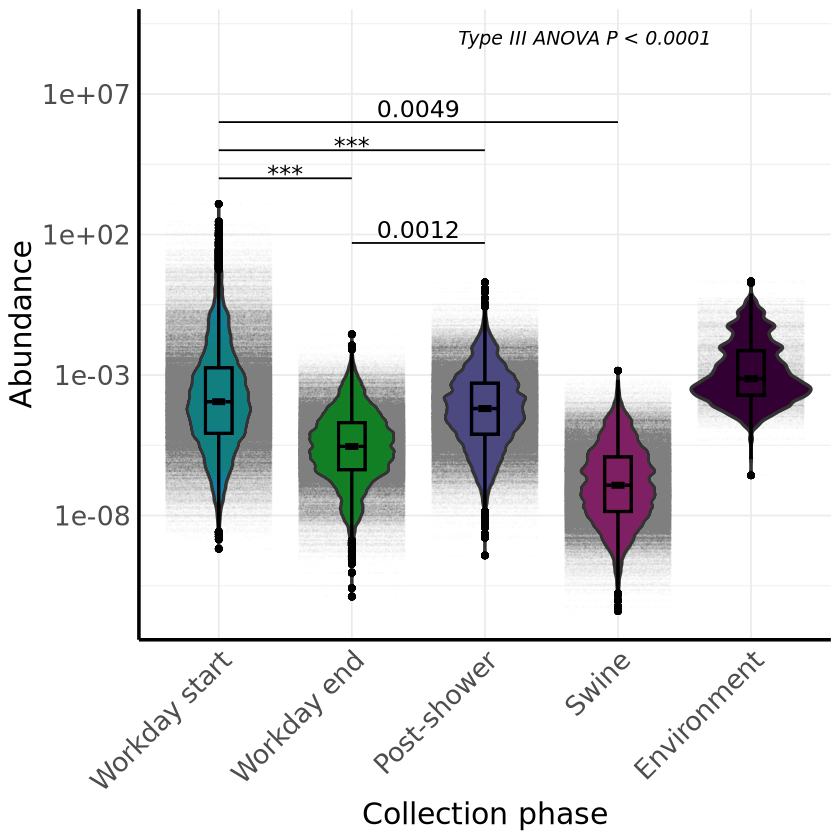

In [52]:
ARGQUANT_PLOT+ geom_text(data = tibble(x=3.75, y=1e+9), size=4, aes(x=x, y=y, label= "Type III ANOVA P < 0.0001", fontface="italic"),inherit.aes=FALSE)+  
geom_line(data=tibble(x=c(1,2), y=c(1e+4,1e+4)), aes(x=x, y=y), inherit.aes=FALSE) + geom_text(data = tibble(x=1.5, y=1.5e+4), size=5, aes(x=x, y=y, label= "***"),inherit.aes=FALSE) + 
geom_line(data=tibble(x=c(1,3), y=c(1e+5,1e+5)), aes(x=x, y=y), inherit.aes=FALSE) + geom_text(data = tibble(x=2, y=1.5e+5), size=5, aes(x=x, y=y, label= "***"),inherit.aes=FALSE) + 
geom_line(data=tibble(x=c(1,4), y=c(1e+6,1e+6)), aes(x=x, y=y), inherit.aes=FALSE) + geom_text(data = tibble(x=2.5, y=3e+6), size=5, aes(x=x, y=y, label= "0.0049"),inherit.aes=FALSE) +
geom_line(data=tibble(x=c(2,3), y=c(50,50)), aes(x=x, y=y), inherit.aes=FALSE) + geom_text(data = tibble(x=2.5, y=150), size=5, aes(x=x, y=y, label= "0.0012"),inherit.aes=FALSE) +

theme(axis.text.x = element_text(size = 16), axis.text.y = element_text(size = 16), text=element_text(family="Helvetica Neue Medium",  size=18))+
  theme(axis.text.x = element_text(angle = 45, hjust = 1), axis.line = element_line(size = 1))+
  theme(legend.position = "none") 

In [ ]:
library(svglite)

In [53]:
ggsave("ARGQUANT.svg", width = 40, height = 40, units = "cm")

In [13]:
# Relevel the CollectionPhase.x factor to set 'WORKDAY_START' as the reference level
# Convert CollectionPhase.x to an unordered factor if it isn't already
df_long$CollectionPhase.x <- factor(df_long$CollectionPhase.x, levels = unique(df_long$CollectionPhase.x))

# Now relevel the factor to set 'WORKDAY_START' as the reference level
df_long$CollectionPhase.x <- relevel(df_long$CollectionPhase.x, ref = "WORKDAY_START")
model_ARG_ABUND<-
  lmer(Abundance ~ CollectionPhase.x +(1|Worker.x), data = df_long, REML=F)

In [14]:
summary(model_ARG_ABUND)

Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: Abundance ~ CollectionPhase.x + (1 | Worker.x)
   Data: df_long

     AIC      BIC   logLik deviance df.resid 
15587851 15587940 -7793919 15587837  2488073 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
 -0.264  -0.047   0.000   0.022 219.998 

Random effects:
 Groups   Name        Variance Std.Dev.
 Worker.x (Intercept)  0.05956 0.2441  
 Residual             30.78672 5.5486  
Number of obs: 2488080, groups:  Worker.x, 22

Fixed effects:
                               Estimate Std. Error         df t value Pr(>|t|)
(Intercept)                   3.842e-01  7.750e-02  2.224e+01   4.958 5.67e-05
CollectionPhase.xPOST_SHOWER -3.817e-01  1.001e-02  2.488e+06 -38.120  < 2e-16
CollectionPhase.xSWINE       -3.842e-01  1.096e-01  2.225e+01  -3.505  0.00197
CollectionPhase.xWORKDAY_END -4.183e-01  1.031e-02  2.483e+06 -40.572  < 2e-16
CollectionPhase.xENVIRONMENT -3.618e

In [34]:
ARG_ABUND_SUMMARY<-emmeans(model_ARG_ABUND, pairwise ~ CollectionPhase.x, adjust = "BH", lmerTest.limit = 3488080)

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 2488080' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 2488080)' or larger];
but be warned that this may result in large computation time and memory use.



In [36]:
ARG_ABUND_SUMMARY

$emmeans
 CollectionPhase.x    emmean     SE   df lower.CL upper.CL
 WORKDAY_START      3.84e-01 0.0775 22.2    0.224    0.545
 POST_SHOWER        2.51e-03 0.0775 22.2   -0.158    0.163
 SWINE              4.50e-06 0.0775 22.3   -0.161    0.161
 WORKDAY_END       -3.40e-02 0.0775 22.3   -0.195    0.127
 ENVIRONMENT        2.25e-02 0.1740 22.4   -0.337    0.382

Degrees-of-freedom method: satterthwaite 
Confidence level used: 0.95 

$contrasts
 contrast                    estimate     SE       df t.ratio p.value
 WORKDAY_START - POST_SHOWER  0.38172 0.0100 2.49e+06  38.120  <.0001
 WORKDAY_START - SWINE        0.38423 0.1100 2.23e+01   3.505  0.0049
 WORKDAY_START - WORKDAY_END  0.41828 0.0103 2.48e+06  40.572  <.0001
 WORKDAY_START - ENVIRONMENT  0.36176 0.1900 2.24e+01   1.903  0.1401
 POST_SHOWER - SWINE          0.00251 0.1100 2.22e+01   0.023  0.9819
 POST_SHOWER - WORKDAY_END    0.03656 0.0103 2.48e+06   3.562  0.0012
 POST_SHOWER - ENVIRONMENT   -0.01996 0.1900 2.24e+01  -0.105  

In [179]:
mob_mat<-read.csv("~/Resistome_mobilome_re_analysis/Supplementary_datafile_7_mobilome.data.file.counts.GigaRevised.csv", header = TRUE)       
annot_mat<- read.csv("~/Resistome_mobilome_re_analysis/Supplementary_datafile_8_mobilome.data.file.annotation.GigaRevised.csv", header = TRUE)
mobilomesamples_df <- read.csv("~/Resistome_mobilome_re_analysis/Supplementary_datafile_1_metadata_FINAL_MCOHS_WORKER_METADATA_GigaRevised.csv", header = TRUE)

In [180]:
##need to have row.names
row.names(mob_mat) <- mob_mat$Genes

In [181]:
mob_mat <- mob_mat %>% dplyr::select(-Genes) #remove the column Genes since it is now used as a row name

In [182]:
row.names(annot_mat) <- annot_mat$Genes

In [183]:
annot_mat <- annot_mat %>% dplyr::select(-Genes) 

In [184]:
row.names(mobilomesamples_df) <- mobilomesamples_df$NovSeq_SS_Lib_ID

In [185]:
mobilomesamples_df <- mobilomesamples_df %>% dplyr::select(-NovSeq_SS_Lib_ID)

In [186]:
#Transform into matrixes otu and tax tables (sample table can be left as data frame)
mob_mat <- as.matrix(mob_mat)

In [160]:
annot_mat <- apply(annot_mat, 2, as.character)

In [187]:
annot_mat <- as.matrix(annot_mat)

In [188]:
class(annot_mat)

[1] "matrix" "array"

In [163]:
str(annot_mat)


 chr [1:7572, 1:10] "Virus" "Virus" "Prophage" "Virus" "Prophage" ...
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:10] "Type" "Plasmid_structural_accessory_genes" "Gene_description" "Locus" ...


In [142]:
annot_mat <- as.matrix(annot_mat)


In [143]:
dim(annot_mat)

[1] 7572   10

In [144]:
class(annot_mat)

[1] "matrix" "array"

In [145]:
mode(annot_mat)

[1] "character"

In [146]:
str(annot_mat)

 chr [1:7572, 1:10] "Virus" "Virus" "Prophage" "Virus" "Prophage" ...
 - attr(*, "dimnames")=List of 2
  ..$ : NULL
  ..$ : chr [1:10] "Type" "Plasmid_structural_accessory_genes" "Gene_description" "Locus" ...


In [133]:
any(is.na(annot_mat))

[1] TRUE

In [134]:
rownames(annot_mat)

NULL

In [189]:
##phyloseq:
MOBILOME = otu_table(mob_mat, taxa_are_rows = T)


In [190]:
GENES <- phyloseq::tax_table(annot_mat)


In [191]:
MOB_SAMPLES = sample_data(mobilomesamples_df)

In [192]:
# Check if they match
setdiff(taxa_names(MOBILOME), taxa_names(GENES))  # Taxa in OTU but not in Taxonomy


character(0)

In [193]:
setdiff(taxa_names(GENES), taxa_names(MOBILOME))  # Taxa in Taxonomy but not in OTU

character(0)

In [194]:
taxa_names(GENES) %>% head()
taxa_names(MOBILOME) %>% head()


[1] "gene:vir:6598"     "gene:vir:10465"    "gene:proph:171872"
[4] "gene:vir:96268"    "gene:proph:172455" "gene:proph:184737"

[1] "gene:vir:6598"     "gene:vir:10465"    "gene:proph:171872"
[4] "gene:vir:96268"    "gene:proph:172455" "gene:proph:184737"

In [195]:
MOBILOME_physeq <- phyloseq(MOBILOME, GENES, MOB_SAMPLES)

In [196]:
saveRDS(MOBILOME_physeq,"~/Resistome_mobilome_re_analysis/REVISION_initial.mobilome.phyloseq")

In [14]:
MOBILOME_physeq <- readRDS("~/Resistome_mobilome_re_analysis/REVISION_initial.mobilome.phyloseq")

In [15]:
# Extract the OTU counts table (AMR gene counts)
otu_table_data <- otu_table(MOBILOME_physeq)

In [16]:
# Extract the taxonomy table (AMR gene classification)
tax_table_data <- phyloseq::tax_table(MOBILOME_physeq)

In [17]:
# Extract the sample data (16S qPCR copy number)
sample_data <- sample_data(MOBILOME_physeq)

In [3]:
mobilomesamples_df <- read.csv("~/Resistome_mobilome_re_analysis/Supplementary_datafile_1_metadata_FINAL_MCOHS_WORKER_METADATA_GigaRevised.csv", header = TRUE)

In [19]:
# Remove commas and convert qPCR_16S_copy_number to numeric
sample_data$qpcr_16s_copies_ul <- gsub(",", "", sample_data$qpcr_16s_copies_ul)


In [20]:
N_16S_sequence <- as.numeric(sample_data$qpcr_16s_copies_ul)

In [21]:
# Merge the tax_table with gene lengths (though we won’t use lengths for normalization)
tax_table_data <- as.data.frame(tax_table_data)


In [22]:
tax_table_data$Genes <- rownames(tax_table_data)  # Ensure genes are properly indexed

In [23]:
# Ensure sample names are aligned
names(N_16S_sequence) <- colnames(otu_table_data)


In [24]:
N_16S_sequence <- N_16S_sequence[match(colnames(otu_table_data), names(N_16S_sequence))]

In [123]:
abundance_data <- data.frame()
# Loop over each gene (OTU) to calculate abundance per sample
for (Gene in 1:nrow(otu_table_data)) {
  otu_column <- as.numeric(otu_table_data[Gene, ])  # Ensure numeric
  gene_name <- rownames(otu_table_data)[Gene]  # Gene name

  # Ensure dimensions match
  if (length(otu_column) != length(N_16S_sequence)) {
    stop("Mismatch in dimensions between OTU counts and 16S sequence lengths.")
  }

  # Calculate abundance (without normalizing by gene length)
  numerator <- otu_column  # Raw counts
  denominator <- N_16S_sequence  # Normalize only by 16S qPCR and resistome hits

  # Compute abundance, avoiding division by zero
  abundance <- ifelse(denominator == 0, NA, numerator / denominator)

  # Store abundance data
  abundance_data <- rbind(abundance_data, data.frame(Gene = rep(gene_name, length(abundance)), 
                                                    Sample = colnames(otu_table_data),  # Add sample names
    Abundance = abundance
  ))
}

In [124]:
abundance_data

,Gene,Sample,Abundance
,<chr>,<chr>,<dbl>
R1_8,gene:vir:6598,R1_8,0.00000e+00
R2_2,gene:vir:6598,R2_2,0.00000e+00
R2_3,gene:vir:6598,R2_3,0.00000e+00
R2_17,gene:vir:6598,R2_17,0.00000e+00
R2_11,gene:vir:6598,R2_11,0.00000e+00
R2_4,gene:vir:6598,R2_4,0.00000e+00
R2_13,gene:vir:6598,R2_13,0.00000e+00
R2_16,gene:vir:6598,R2_16,0.00000e+00
R1_19,gene:vir:6598,R1_19,0.00000e+00


In [125]:
write.csv(abundance_data, "~/Resistome_mobilome_re_analysis/init_MOB_QUANT.csv", row.names = FALSE)

In [2]:
abundance_data<- read.csv("~/Resistome_mobilome_re_analysis/init_MOB_QUANT.csv")

In [4]:
# Merge abundance data with mobilomesamples_df to add sample metadata, including NovSeq_SS_Lib_ID
abundance_data <- left_join(abundance_data, mobilomesamples_df, by = c("Sample" = "NovSeq_SS_Lib_ID"))


In [5]:
abundance_data

Gene,Sample,Abundance,X16S_NCBI_accession,Metagenomic_NCBI_accession,study,bioproject_accession,biosample_accession,SampleName,Worker,⋯,Perc_Qualitytrim_Rem,Shotgun_Post_Host_Rem,Host_ReadCount,Perc_HostCount,Resistome_hits,Resistome_targ_rate,Resistome_Duplication_rate,Mobilome_hits,Mobilome_targ_rate,Mobilome_Duplication_rate
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
gene:vir:6598,R1_8,0.00000e+00,SRR30653053,SRR30645933,SRP532316,PRJNA987158,SAMN43702708,SWK8A,SWK8,⋯,8.307457,17103807,38340628,69.15145,2205176,5.751538551,4.03734389,2104036,5.48774527,3.57262536
gene:vir:6598,R2_2,0.00000e+00,SRR30653074,SRR30645930,SRP532316,PRJNA987158,SAMN43702726,SWK6C,SWK6,⋯,5.674737,25145044,31823370,55.86143,8711424,27.374297570,25.15312803,3763022,11.82471247,10.15539838
gene:vir:6598,R2_3,0.00000e+00,SRR30653073,SRR30645929,SRP532316,PRJNA987158,SAMN43702727,SWK7C,SWK7,⋯,4.043086,20694517,29885193,59.08534,4119403,13.784093680,10.80782045,2928796,9.80015756,6.19174519
gene:vir:6598,R2_17,0.00000e+00,SRR30653057,SRR30645937,SRP532316,PRJNA987158,SAMN43702741,ENVAF,ENVIRONMENT_FARROWING,⋯,8.526032,43341941,13948573,24.34709,9593159,68.775200160,64.27142762,7756876,55.61053450,47.02275279
gene:vir:6598,R2_11,0.00000e+00,SRR30653064,SRR30645920,SRP532316,PRJNA987158,SAMN43702735,SW5,PEN5,⋯,3.466950,37669204,36925795,49.50170,9087828,24.611055770,21.99724610,5481941,14.84583067,11.00020189
gene:vir:6598,R2_4,0.00000e+00,SRR30653072,SRR30645928,SRP532316,PRJNA987158,SAMN43702728,SWK8C,SWK8,⋯,6.717981,33348921,23141406,40.96525,13123066,56.708161980,54.05405791,8899520,38.45712745,34.96866180
gene:vir:6598,R2_13,0.00000e+00,SRR30653062,SRR30645918,SRP532316,PRJNA987158,SAMN43702737,SW7,PEN7,⋯,4.799676,60807855,53919780,46.99808,8007880,14.851470090,13.14295236,7307794,13.55308571,10.82887022
gene:vir:6598,R2_16,0.00000e+00,SRR30653059,SRR30645915,SRP532316,PRJNA987158,SAMN43702740,SW10,PEN10,⋯,9.068792,43550045,16365833,27.31468,8508168,51.987381270,46.88713370,6963859,42.55120408,33.61354109
gene:vir:6598,R1_19,0.00000e+00,SRR30653082,SRR30645946,SRP532316,PRJNA987158,SAMN43702719,SWK9B,SWK9,⋯,11.436020,1757943,2442318,58.14682,233,0.009540117,-0.05793676,2108,0.08631145,0.07836817


In [6]:
library(tidyr)
library(tibble)
library(stringr)


Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack




In [7]:
library(ggplot2)

In [8]:
df_long_mob <- abundance_data %>%
  mutate(CollectionPhase = factor(CollectionPhase, 
                                    levels = c("WORKDAY_START", "WORKDAY_END", "POST_SHOWER", "SWINE", "ENVIRONMENT"))) %>%
  filter(Abundance > 0)


In [35]:
MOBQUANT_PLOT<-ggplot(df_long_mob, aes(x = CollectionPhase, y = Abundance, fill = CollectionPhase)) +
  geom_violin(trim=TRUE, alpha= 1, position=position_dodge(), size=1) +
  #ggbeeswarm::geom_quasirandom(shape = 16,size=0.002, dodge.width = .75, color="black",alpha=.05,show.legend = F)+
  geom_boxplot(notch = TRUE, color="black",lwd=1, alpha = 0.3, width=0.2,show.legend = F)+
  geom_point(alpha = 0.05, size = 0.005, position = position_jitter(width=0.4), color="black")+  # Adds individual points with transparency
theme_minimal() + scale_x_discrete("Collection phase", labels= c("WORKDAY_START"= "Workday start", "WORKDAY_END"="Workday end", "POST_SHOWER"="Post-shower", "SWINE"="Swine", "ENVIRONMENT"="Environment"))+
  scale_y_continuous(trans = "log10")+ labs(x=NULL,color= NULL)+
scale_fill_manual(name = "Collection phase", 
                  values = c("WORKDAY_START" = "#119dd9", 
                             "WORKDAY_END" = "#13A825", 
                             "POST_SHOWER" = "#4B49C4", 
                             "SWINE" = "#9D2064", 
                             "ENVIRONMENT" = "#330033"),
                  labels = c("Workday start", "Workday end", 
                             "Post-shower", "Swine", "Environment"))

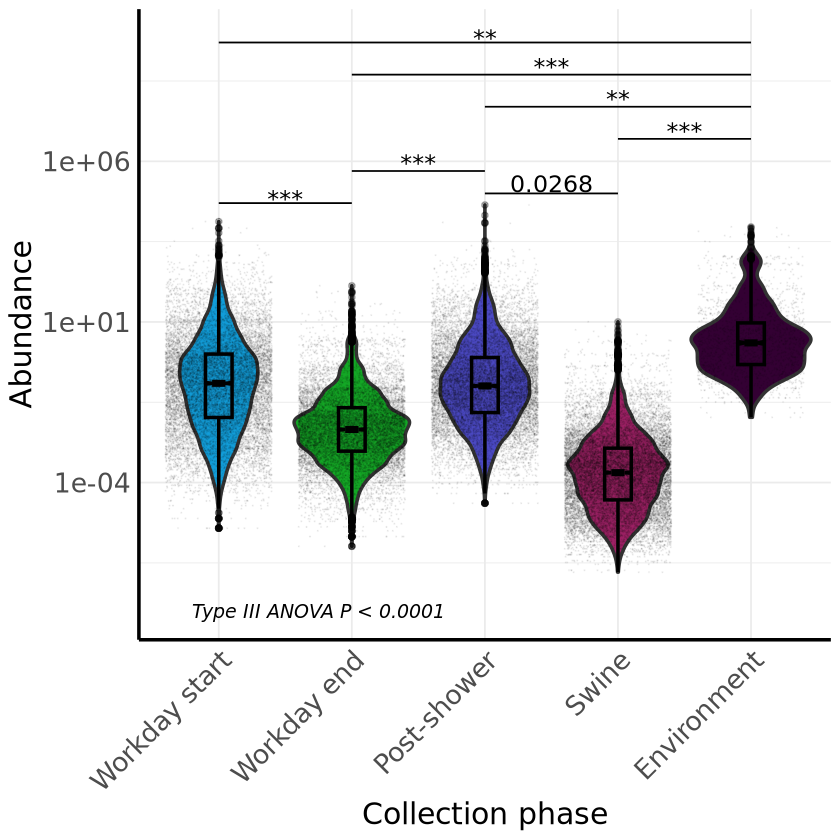

In [37]:
MOBQUANT_PLOT+ geom_text(data = tibble(x=1.75, y=1e-8), size=4, aes(x=x, y=y, label= "Type III ANOVA P < 0.0001", fontface="italic"),inherit.aes=FALSE)+  
geom_line(data=tibble(x=c(1,2), y=c(5e+4,5e+4)), aes(x=x, y=y), inherit.aes=FALSE) + geom_text(data = tibble(x=1.5, y=7e+4), size=5, aes(x=x, y=y, label= "***"),inherit.aes=FALSE) + 
geom_line(data=tibble(x=c(1,5), y=c(5e+9,5e+9)), aes(x=x, y=y), inherit.aes=FALSE) + geom_text(data = tibble(x=3, y=7e+9), size=5, aes(x=x, y=y, label= "**"),inherit.aes=FALSE) +
geom_line(data=tibble(x=c(3,4), y=c(1e+5,1e+5)), aes(x=x, y=y), inherit.aes=FALSE) + geom_text(data = tibble(x=3.5, y=2e+5), size=5, aes(x=x, y=y, label= "0.0268"),inherit.aes=FALSE) +
geom_line(data=tibble(x=c(2,3), y=c(5e+5,5e+5)), aes(x=x, y=y), inherit.aes=FALSE) + geom_text(data = tibble(x=2.5, y=9e+5), size=5, aes(x=x, y=y, label= "***"),inherit.aes=FALSE) +
geom_line(data=tibble(x=c(2,5), y=c(5e+8,5e+8)), aes(x=x, y=y), inherit.aes=FALSE) + geom_text(data = tibble(x=3.5, y=9e+8), size=5, aes(x=x, y=y, label= "***"),inherit.aes=FALSE) +
geom_line(data=tibble(x=c(3,5), y=c(5e+7,5e+7)), aes(x=x, y=y), inherit.aes=FALSE) + geom_text(data = tibble(x=4, y=9e+7), size=5, aes(x=x, y=y, label= "**"),inherit.aes=FALSE) +
geom_line(data=tibble(x=c(4,5), y=c(5e+6,5e+6)), aes(x=x, y=y), inherit.aes=FALSE) + geom_text(data = tibble(x=4.5, y=9e+6), size=5, aes(x=x, y=y, label= "***"),inherit.aes=FALSE) +

theme(axis.text.x = element_text(size = 16), axis.text.y = element_text(size = 16), text=element_text(family="Helvetica Neue Medium",  size=18))+
  theme(axis.text.x = element_text(angle = 45, hjust = 1), axis.line = element_line(size = 1))+
  theme(legend.position = "none") 

In [38]:
library(svglite)

In [39]:
ggsave("MOBQUANT.svg", width = 40, height = 40, units = "cm")

In [73]:
# Relevel the CollectionPhase.x factor to set 'WORKDAY_START' as the reference level
# Convert CollectionPhase.x to an unordered factor if it isn't already
df_long_mob$CollectionPhase <- factor(df_long_mob$CollectionPhase, levels = unique(df_long_mob$CollectionPhase))

# Now relevel the factor to set 'WORKDAY_START' as the reference level
df_long_mob$CollectionPhase <- relevel(df_long_mob$CollectionPhase, ref = "WORKDAY_START")
model_MOB_ABUND<-
  lmer(Abundance ~ CollectionPhase +(1|Worker), data = df_long_mob, REML=F)

In [74]:
summary(model_MOB_ABUND)

Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: Abundance ~ CollectionPhase + (1 | Worker)
   Data: df_long_mob

      AIC       BIC    logLik  deviance  df.resid 
 844536.8  844599.9 -422261.4  844522.8     60864 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
 -0.331  -0.036   0.000   0.000 175.560 

Random effects:
 Groups   Name        Variance Std.Dev.
 Worker   (Intercept)   238.9   15.46  
 Residual             62022.4  249.04  
Number of obs: 60871, groups:  Worker, 22

Fixed effects:
                            Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)                   14.745      5.330    27.023   2.766   0.0101 *  
CollectionPhaseSWINE         -14.734      7.487    26.275  -1.968   0.0597 .  
CollectionPhaseWORKDAY_END   -19.418      3.114 59245.834  -6.236 4.51e-10 ***
CollectionPhasePOST_SHOWER     4.006      2.978 60858.565   1.345   0.1786    
CollectionPhaseENVIRONMENT    

In [75]:
emmeans(model_MOB_ABUND, pairwise ~ CollectionPhase, adjust = "BH", lmerTest.limit = 444475)

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 60871' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 60871)' or larger];
but be warned that this may result in large computation time and memory use.



$emmeans
 CollectionPhase  emmean    SE   df lower.CL upper.CL
 WORKDAY_START   14.7453  5.33 27.0     3.81    25.68
 SWINE            0.0118  5.26 25.5   -10.81    10.83
 WORKDAY_END     -4.6724  5.38 28.1   -15.70     6.35
 POST_SHOWER     18.7508  5.32 26.8     7.84    29.66
 ENVIRONMENT     75.7900 12.20 30.0    50.80   100.78

Degrees-of-freedom method: satterthwaite 
Confidence level used: 0.95 

$contrasts
 contrast                    estimate    SE      df t.ratio p.value
 WORKDAY_START - SWINE          14.73  7.49    26.3   1.968  0.0747
 WORKDAY_START - WORKDAY_END    19.42  3.11 59245.8   6.236  <.0001
 WORKDAY_START - POST_SHOWER    -4.01  2.98 60858.6  -1.345  0.1984
 WORKDAY_START - ENVIRONMENT   -61.04 13.30    29.5  -4.574  0.0002
 SWINE - WORKDAY_END             4.68  7.53    26.8   0.622  0.5389
 SWINE - POST_SHOWER           -18.74  7.48    26.1  -2.506  0.0268
 SWINE - ENVIRONMENT           -75.78 13.30    29.2  -5.691  <.0001
 WORKDAY_END - POST_SHOWER     -23.42  